# 🌾 Smart Harvest AI — XGBoost & LightGBM Evaluation
Comparing XGBoost and LightGBM against the existing **RF + GB Hybrid** for:
- **Yield Prediction** (Regression → R², MAE, RMSE)


In [13]:
import subprocess, sys
for pkg in ['xgboost', 'lightgbm']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
        print(f'Installed {pkg}')

In [14]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb

BASE_DIR  = Path('..').resolve()
DATA_PATH = BASE_DIR / 'FINAL_DATASET_cleaned.csv'
print('Dataset path:', DATA_PATH)
print('Exists:', DATA_PATH.exists())

Dataset path: /Users/ayushvishnoi/Documents/GitHub/smart_harvest.ai/FINAL_DATASET_cleaned.csv
Exists: True


---
## 1. Load & Preprocess

In [15]:
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
df.rename(columns={'avgtemp_c': 'AvgTemp_C', 'humidity_perc': 'Humidity_perc'}, inplace=True)

CAT_COLS = ['state', 'district', 'crop', 'season']
for col in CAT_COLS:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Same cleaning as train_yield_model_v2.py
if 'production' in df.columns:
    df.drop(columns=['production'], inplace=True)
df = df[~df['crop'].str.contains('coconut', na=False)]
df.dropna(subset=['yield'], inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

q_low, q_high = df['yield'].quantile(0.02), df['yield'].quantile(0.98)
df = df[(df['yield'] >= q_low) & (df['yield'] <= q_high)]
if 'AvgTemp_C' in df.columns:
    df = df[(df['AvgTemp_C'] >= 0) & (df['AvgTemp_C'] <= 45)]

le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print(f'Clean dataset: {len(df):,} rows')
df.head(3)

Clean dataset: 224,335 rows


,state,district,crop,crop_year,season,area,yield,latitude,longitude,AvgTemp_C,Humidity_perc,ph,organic_carbon_g_kg,clay_g_kg,sand_g_kg,total_rainfall_mm
0,15,210,0,2006,4,3416.0,1.48,9.873821,77.013261,21.8,87,5.3,52.5,321,386,2690.34
1,2,39,0,2006,4,4136.0,0.77,26.666007,91.341537,20.2,48,5.4,19.5,273,390,1536.47
2,31,84,0,1999,4,14.0,1.07,23.951730,87.661595,24.7,72,6.1,30.2,231,369,1247.31


---
## 2. Yield Prediction — Regression

In [16]:
YIELD_FEATURES = ['state', 'district', 'crop', 'crop_year', 'season',
                  'area', 'latitude', 'longitude', 'total_rainfall_mm',
                  'AvgTemp_C', 'Humidity_perc', 'ph',
                  'organic_carbon_g_kg', 'clay_g_kg', 'sand_g_kg']
YIELD_FEATURES = [f for f in YIELD_FEATURES if f in df.columns]

# Time-based split (same as original)
X_train = df[df['crop_year'] <= 2015][YIELD_FEATURES]
X_test  = df[df['crop_year'] >  2015][YIELD_FEATURES]
y_train = df[df['crop_year'] <= 2015]['yield']
y_test  = df[df['crop_year'] >  2015]['yield']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 175,797 | Test: 48,538


In [17]:
def reg_metrics(name, y_true, y_pred):
    return {
        'Model': name,
        'R2':    round(r2_score(y_true, y_pred), 4),
        'MAE':   round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)
    }

yield_results = []

# Baseline: RF + GB Hybrid
print('Training RF...')
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=20,
                           max_features=0.7, n_jobs=-1, random_state=42)
rf.fit(X_train_sc, y_train)

print('Training GB...')
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                               min_samples_leaf=20, subsample=0.8, random_state=42)
gb.fit(X_train_sc, y_train)
hybrid_pred = 0.55 * rf.predict(X_test_sc) + 0.45 * gb.predict(X_test_sc)
yield_results.append(reg_metrics('RF + GB Hybrid (baseline)', y_test, hybrid_pred))

# XGBoost
print('Training XGBoost...')
xgb_reg = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=0.1, reg_lambda=1.0,
                       n_jobs=-1, random_state=42, verbosity=0)
xgb_reg.fit(X_train_sc, y_train)
yield_results.append(reg_metrics('XGBoost', y_test, xgb_reg.predict(X_test_sc)))

# LightGBM
print('Training LightGBM...')
lgbm_reg = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              reg_alpha=0.1, reg_lambda=1.0,
                              n_jobs=-1, random_state=42, verbose=-1)
lgbm_reg.fit(X_train_sc, y_train)
yield_results.append(reg_metrics('LightGBM', y_test, lgbm_reg.predict(X_test_sc)))

# XGB + LightGBM Hybrid
xgb_lgbm_pred = 0.5 * xgb_reg.predict(X_test_sc) + 0.5 * lgbm_reg.predict(X_test_sc)
yield_results.append(reg_metrics('XGB + LightGBM Hybrid', y_test, xgb_lgbm_pred))

yield_df = pd.DataFrame(yield_results).set_index('Model')
print('\nYield Results:')
yield_df

Training RF...
Training GB...
Training XGBoost...
Training LightGBM...

Yield Results:


,R2,MAE,RMSE
Model,,,
RF + GB Hybrid (baseline),0.7900,1.2962,2.7330
XGBoost,0.8235,1.1800,2.5058
LightGBM,0.8106,1.2612,2.5954
XGB + LightGBM Hybrid,0.8193,1.2104,2.5355


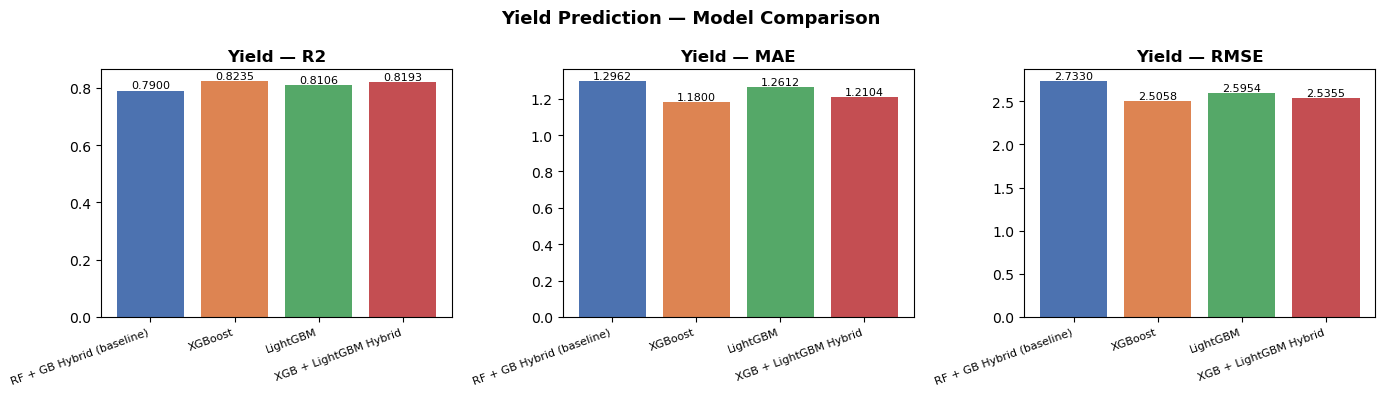

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, metric in zip(axes, ['R2', 'MAE', 'RMSE']):
    bars = ax.bar(yield_df.index, yield_df[metric], color=colors)
    ax.set_title(f'Yield — {metric}', fontweight='bold')
    ax.set_xticklabels(yield_df.index, rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, yield_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Yield Prediction — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Irrigation Classification (FAO-56 Based Label — No Leakage)
### Why the old label was wrong
The original `irr_score` was computed from `total_rainfall_mm`, `AvgTemp_C`, `Humidity_perc`, and `ph` — the **same columns used as features**.
Any model trivially reverse-engineers the formula → fake ~100% accuracy.

### Fix: FAO-56 Crop Water Requirement
Label is now based on **crop-specific water demand (ETc mm/season)** from FAO-56 standards,
minus effective rainfall. The model must learn from crop type, soil, location, and season —
**not** from the weather features that define the label.

In [19]:
# FAO-56 crop water requirement lookup (ETc mm/season) — domain knowledge, not derived from features
FAO_ETc = {
    'rice': 1200, 'wheat': 450, 'maize': 500, 'sugarcane': 1500,
    'cotton(lint)': 700, 'groundnut': 500, 'soyabean': 450,
    'jowar': 350, 'bajra': 300, 'ragi': 350, 'barley': 400,
    'gram': 300, 'arhar/tur': 400, 'moong(green gram)': 300,
    'urad': 300, 'masoor': 300, 'peas & beans (pulses)': 350,
    'linseed': 350, 'rapeseed &mustard': 350, 'sunflower': 500,
    'sesamum': 350, 'castor seed': 450, 'safflower': 400,
    'potato': 500, 'onion': 350, 'garlic': 350,
    'banana': 1200, 'sugarcane': 1500, 'tapioca': 800,
    'sweet potato': 500, 'ginger': 600, 'turmeric': 600,
    'dry chillies': 400, 'coriander': 300,
    'jute': 500, 'sannhamp': 450, 'mesta': 450,
    'tobacco': 400, 'arecanut': 1800, 'coconut': 1500,
    'cashewnut': 900, 'black pepper': 1500, 'cardamom': 1200,
    'horse-gram': 250, 'cowpea(lobia)': 350, 'moth': 250,
    'guar seed': 300, 'niger seed': 300, 'khesari': 300,
    'small millets': 300, 'other cereals': 400,
    'other kharif pulses': 350, 'other  rabi pulses': 350,
    'other summer pulses': 350, 'oilseeds total': 400,
    'other oilseeds': 400,
}
DEFAULT_ETc = 450  # fallback for unmapped crops

# Reload fresh
df_irr = pd.read_csv(DATA_PATH)
df_irr.columns = [c.strip().lower().replace(' ', '_') for c in df_irr.columns]
df_irr.rename(columns={'avgtemp_c': 'AvgTemp_C', 'humidity_perc': 'Humidity_perc'}, inplace=True)

for col in ['crop', 'state', 'season']:
    df_irr[col] = df_irr[col].astype(str).str.strip().str.lower()

df_irr.dropna(subset=['total_rainfall_mm', 'AvgTemp_C', 'Humidity_perc'], inplace=True)
df_irr.fillna(df_irr.median(numeric_only=True), inplace=True)

# FAO-56 label: crop water demand minus effective rainfall (80% of rainfall is effective)
df_irr['crop_ETc']        = df_irr['crop'].map(FAO_ETc).fillna(DEFAULT_ETc)
df_irr['eff_rainfall']    = df_irr['total_rainfall_mm'] * 0.8
df_irr['irrigation_need_mm'] = (df_irr['crop_ETc'] - df_irr['eff_rainfall']).clip(lower=0)

# Bin into 4 classes based on actual irrigation deficit
df_irr['irrigation_need'] = pd.cut(
    df_irr['irrigation_need_mm'],
    bins=[-1, 100, 400, 800, 99999],
    labels=['Low', 'Moderate', 'High', 'Very High']
)
df_irr.dropna(subset=['irrigation_need'], inplace=True)

print('Label distribution:')
print(df_irr['irrigation_need'].value_counts().sort_index())

# Features: crop, soil, location, season — NO weather columns that define the label
IRR_FEATURES = ['crop', 'state', 'season', 'latitude', 'longitude',
                'ph', 'clay_g_kg', 'sand_g_kg', 'organic_carbon_g_kg']
IRR_FEATURES = [f for f in IRR_FEATURES if f in df_irr.columns]
print('Features used:', IRR_FEATURES)

for col in ['crop', 'state', 'season']:
    le = LabelEncoder()
    df_irr[col] = le.fit_transform(df_irr[col])

le_target = LabelEncoder()
y_irr = le_target.fit_transform(df_irr['irrigation_need'])

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    df_irr[IRR_FEATURES], y_irr, test_size=0.2, random_state=42
)
irr_scaler = StandardScaler()
Xi_train_sc = irr_scaler.fit_transform(Xi_train)
Xi_test_sc  = irr_scaler.transform(Xi_test)

print(f'\nIrrigation — Train: {len(Xi_train):,} | Test: {len(Xi_test):,}')
print('Classes:', le_target.classes_)

Label distribution:
irrigation_need
Low          211285
Moderate      13269
High           7448
Very High      3988
Name: count, dtype: int64
Features used: ['crop', 'state', 'season', 'latitude', 'longitude', 'ph', 'clay_g_kg', 'sand_g_kg', 'organic_carbon_g_kg']

Irrigation — Train: 188,792 | Test: 47,198
Classes: ['High' 'Low' 'Moderate' 'Very High']


In [20]:
def clf_metrics(name, y_true, y_pred):
    return {
        'Model':      name,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'F1 (macro)': round(f1_score(y_true, y_pred, average='macro'), 4)
    }

irr_results = []
clf_models  = {}

# Baseline: RF Classifier
print('Training RF Classifier...')
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=15, n_jobs=-1, random_state=42)
rf_clf.fit(Xi_train_sc, yi_train)
clf_models['RF Classifier (baseline)'] = rf_clf
irr_results.append(clf_metrics('RF Classifier (baseline)', yi_test, rf_clf.predict(Xi_test_sc)))

# XGBoost Classifier
print('Training XGBoost Classifier...')
xgb_clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         eval_metric='mlogloss', n_jobs=-1, random_state=42, verbosity=0)
xgb_clf.fit(Xi_train_sc, yi_train)
clf_models['XGBoost Classifier'] = xgb_clf
irr_results.append(clf_metrics('XGBoost Classifier', yi_test, xgb_clf.predict(Xi_test_sc)))

# LightGBM Classifier
print('Training LightGBM Classifier...')
lgbm_clf = lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                n_jobs=-1, random_state=42, verbose=-1)
lgbm_clf.fit(Xi_train_sc, yi_train)
clf_models['LightGBM Classifier'] = lgbm_clf
irr_results.append(clf_metrics('LightGBM Classifier', yi_test, lgbm_clf.predict(Xi_test_sc)))

irr_df = pd.DataFrame(irr_results).set_index('Model')
print('\nIrrigation Results:')
irr_df

Training RF Classifier...
Training XGBoost Classifier...
Training LightGBM Classifier...

Irrigation Results:


,Accuracy,F1 (macro)
Model,,
RF Classifier (baseline),0.9402,0.7114
XGBoost Classifier,0.9413,0.7154
LightGBM Classifier,0.9415,0.7187


In [21]:
# Detailed report for best model
best_irr = irr_df['Accuracy'].idxmax()
print(f'Best irrigation model: {best_irr}\n')
print(classification_report(yi_test, clf_models[best_irr].predict(Xi_test_sc),
                             target_names=le_target.classes_))

Best irrigation model: LightGBM Classifier

              precision    recall  f1-score   support

        High       0.61      0.65      0.63      1426
         Low       0.97      0.99      0.98     42250
    Moderate       0.63      0.43      0.51      2723
   Very High       0.73      0.78      0.75       799

    accuracy                           0.94     47198
   macro avg       0.74      0.71      0.72     47198
weighted avg       0.94      0.94      0.94     47198



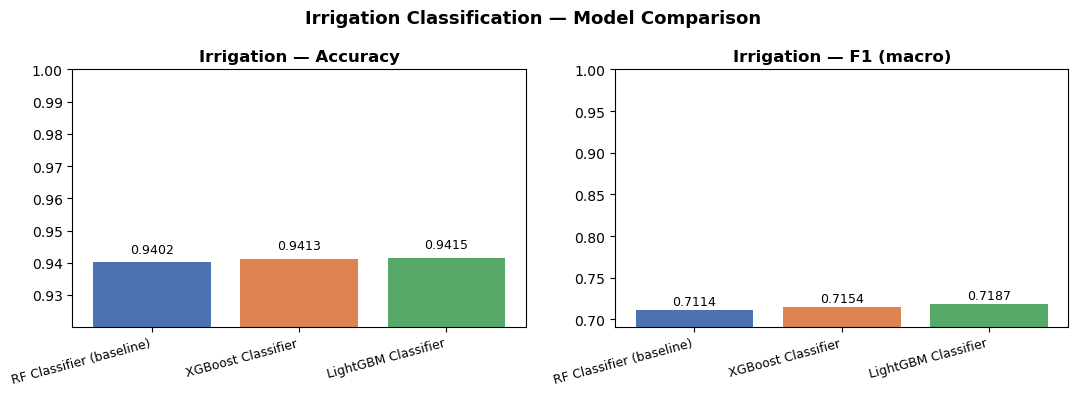

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, metric in zip(axes, ['Accuracy', 'F1 (macro)']):
    bars = ax.bar(irr_df.index, irr_df[metric], color=colors)
    ax.set_title(f'Irrigation — {metric}', fontweight='bold')
    ax.set_ylim(irr_df[metric].min() - 0.02, 1.0)
    ax.set_xticklabels(irr_df.index, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, irr_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Irrigation Classification — Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Final Summary

In [23]:
print('=' * 55)
print('  YIELD PREDICTION (higher R2 = better)')
print('=' * 55)
print(yield_df.to_string())

best_yield    = yield_df['R2'].idxmax()
baseline_r2   = yield_df.loc['RF + GB Hybrid (baseline)', 'R2']
best_r2       = yield_df.loc[best_yield, 'R2']
print(f'\n  Best Yield Model  : {best_yield}')
print(f'  R2 improvement    : {best_r2 - baseline_r2:+.4f} vs baseline')

print('\n' + '=' * 55)
print('  IRRIGATION CLASSIFICATION (higher Accuracy = better)')
print('=' * 55)
print(irr_df.to_string())

best_irr      = irr_df['Accuracy'].idxmax()
baseline_acc  = irr_df.loc['RF Classifier (baseline)', 'Accuracy']
best_acc      = irr_df.loc[best_irr, 'Accuracy']
print(f'\n  Best Irrigation Model : {best_irr}')
print(f'  Accuracy improvement  : {best_acc - baseline_acc:+.4f} vs baseline')
print('=' * 55)

  YIELD PREDICTION (higher R2 = better)
                               R2     MAE    RMSE
Model                                            
RF + GB Hybrid (baseline)  0.7900  1.2962  2.7330
XGBoost                    0.8235  1.1800  2.5058
LightGBM                   0.8106  1.2612  2.5954
XGB + LightGBM Hybrid      0.8193  1.2104  2.5355

  Best Yield Model  : XGBoost
  R2 improvement    : +0.0335 vs baseline

  IRRIGATION CLASSIFICATION (higher Accuracy = better)
                          Accuracy  F1 (macro)
Model                                         
RF Classifier (baseline)    0.9402      0.7114
XGBoost Classifier          0.9413      0.7154
LightGBM Classifier         0.9415      0.7187

  Best Irrigation Model : LightGBM Classifier
  Accuracy improvement  : +0.0013 vs baseline
